# Model 4 - GAP + Data Augmentation

Takes the current best model (**plain GAP** — BatchNorm underperformed in model 3)
and adds **data augmentation** to the training set only (random
flips / rotations / shifts / zoom) — the single change. Augmentation shows the
network more varied views of each image, which should reduce overfitting further.

## 1. Setup & imports

Shared pipeline modules, plus `plot_misclassified` from the plots module.

In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "preprocessing", "label_mapping"))
sys.path.append(os.path.join(os.getcwd(), "preprocessing", "data_loader"))
sys.path.append(os.path.join(os.getcwd(), "model"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "model_metrics"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "plots"))

import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

from label_mapping import build_labeled_dataset
from data_loader import build_train_val_test_generators
from gap_cnn import build_gap_cnn
from model_metrics import debug_model, evaluate_model, record_result
from plots import plot_misclassified

## 2. Load & label the dataset

Build the image index (Italian folder → English label, root-relative paths).

In [2]:
df = build_labeled_dataset()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26179 entries, 0 to 26178
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  26179 non-null  object
 1   label_it    26179 non-null  object
 2   label_en    26179 non-null  object
dtypes: object(3)
memory usage: 613.7+ KB


## 3. Preprocess: split, resize, normalize + **augment**

`augment=True` adds random flips/rotations/shifts/zoom to the **train** generator
only — the single change vs model 3. Val/test stay rescale-only for a fair test.

In [3]:
# augment=True -> random flips/rotations/shifts/zoom on TRAIN only.
# val/test stay rescale-only, so the comparison is still fair.
train_generator, val_generator, test_generator = build_train_val_test_generators(
    df, project_root=os.getcwd(), image_size=(128, 128), augment=True
)
train_generator.class_indices

Found 18325 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.


{'butterfly': 0,
 'cat': 1,
 'chicken': 2,
 'cow': 3,
 'dog': 4,
 'elephant': 5,
 'horse': 6,
 'sheep': 7,
 'spider': 8,
 'squirrel': 9}

## 4. Build the CNN (plain GAP)

Reuses the model 2 architecture (Conv blocks → GlobalAveragePooling → Dropout),
the best base so far. The only change vs model 2 is the augmented training data.

In [4]:
model = build_gap_cnn(
    input_shape=train_generator.image_shape,
    num_classes=len(train_generator.class_indices),
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,298 (1.10 MB)

 Trainable params: 288,298 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train — or load a saved model

If `models_saved/gap_aug.keras` exists it's **loaded**; otherwise it trains and
is saved. Augmented training converges slower, so `epochs=40` and `patience=6`.
Set `RETRAIN = True` to force a fresh run.

In [5]:
import time
from tensorflow import keras

# Load the saved model if present so a kernel restart doesn't cost a full
# retrain. Delete the file or set RETRAIN=True to train fresh.
MODEL_PATH = "models_saved/gap_aug.keras"
RETRAIN = False

if not RETRAIN and os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    history, train_time_min = None, None
    print(f"Loaded {MODEL_PATH} (skipped training).")
else:
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    )
    start_time = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=40,
        callbacks=[early_stopping],
    )
    train_time_min = round((time.time() - start_time) / 60, 1)
    print(f"Trained in {train_time_min} min.")

Loaded models_saved/gap_aug.keras (skipped training).


## 6. Training history

With augmentation the train-val gap (`acc_gap`) should be the smallest of all
models — the sign overfitting is under control.

In [6]:
# Training history — only when we actually trained this run.
if history is not None:
    history_df = pd.DataFrame(history.history)
    history_df.index.name = "epoch"
    history_df["acc_gap"] = history_df["accuracy"] - history_df["val_accuracy"]
    display(history_df)
else:
    print("Model was loaded from disk — no training history this run.")

Model was loaded from disk — no training history this run.


## 7. Evaluate: per-class report + confusion matrix

Score on the validation set; per-class report + confusion-matrix heatmap.

123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
              precision    recall  f1-score   support

   butterfly       0.54      0.90      0.68       317
         cat       0.75      0.32      0.45       250
     chicken       0.66      0.84      0.74       464
         cow       0.59      0.49      0.53       280
         dog       0.80      0.63      0.70       730
    elephant       0.60      0.71      0.65       217
       horse       0.63      0.66      0.65       393
       sheep       0.56      0.66      0.61       273
      spider       0.81      0.76      0.78       723
    squirrel       0.56      0.47      0.51       280

    accuracy                           0.67      3927
   macro avg       0.65      0.64      0.63      3927
weighted avg       0.68      0.67      0.66      3927



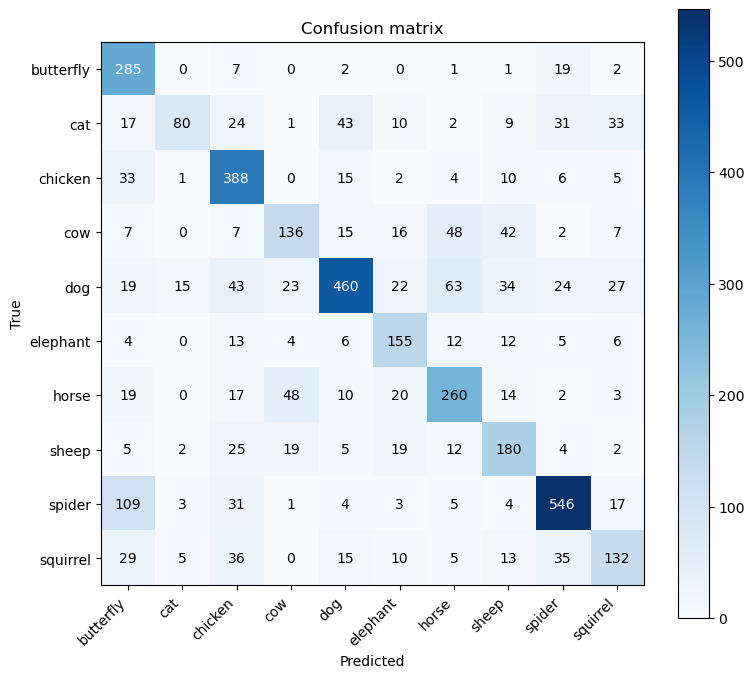

,butterfly,cat,chicken,cow,dog,elephant,horse,sheep,spider,squirrel
butterfly,285,0,7,0,2,0,1,1,19,2
cat,17,80,24,1,43,10,2,9,31,33
chicken,33,1,388,0,15,2,4,10,6,5
cow,7,0,7,136,15,16,48,42,2,7
dog,19,15,43,23,460,22,63,34,24,27
elephant,4,0,13,4,6,155,12,12,5,6
horse,19,0,17,48,10,20,260,14,2,3
sheep,5,2,25,19,5,19,12,180,4,2
spider,109,3,31,1,4,3,5,4,546,17
squirrel,29,5,36,0,15,10,5,13,35,132


In [7]:
# Diagnose on VALIDATION (test set reserved for the final winner only).
debug_model(model, val_generator)

## 8. Misclassified images

Grid of validation images the model got wrong (true → pred) — the mandatory
misclassified-images visualization.

123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step


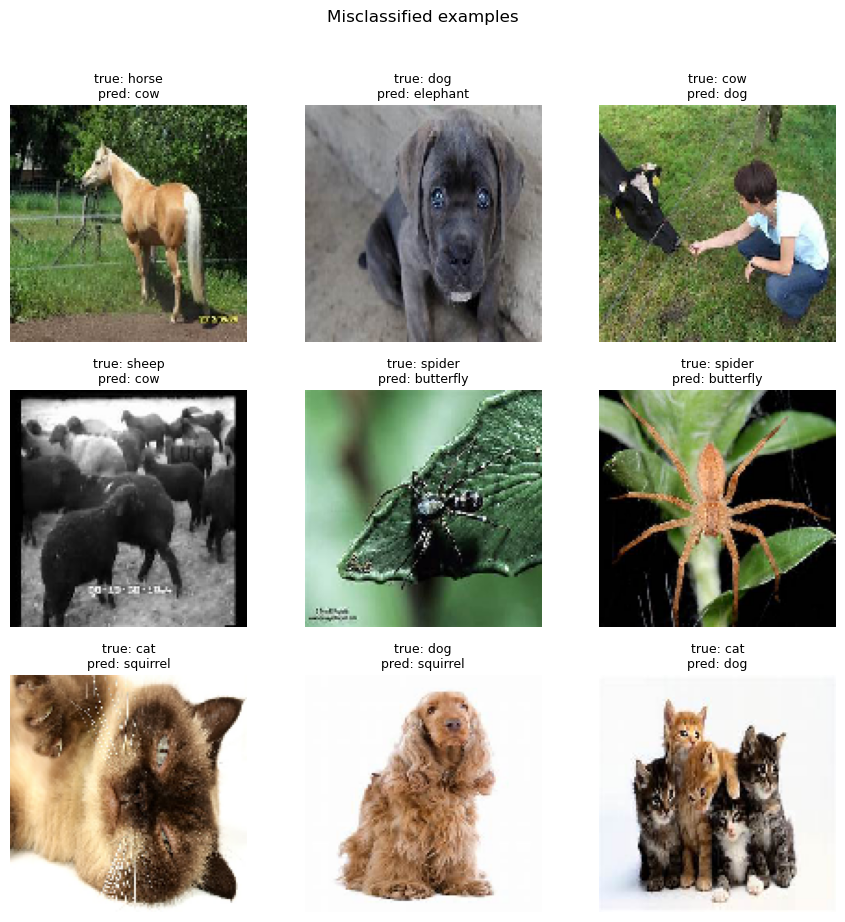

In [8]:
# Mandatory: show a grid of images this model got wrong (true -> pred).
plot_misclassified(model, val_generator)

## 9. Record result to the tracking sheet

Upsert this model's validation row into `model_tracking.csv`.

In [9]:
# Score on VALIDATION and upsert into the shared tracking sheet. learning_rate
# and train_time_min come from the actual run, not hand-typed values.
learning_rate = round(float(model.optimizer.learning_rate.numpy()), 6)

row = evaluate_model(model, val_generator, "gap_aug")
row.update({
    "architecture": "3 conv blocks (6 Conv) -> GlobalAveragePooling -> Dropout(0.5) + augmentation",
    "learning_rate": learning_rate,
    "train_time_min": train_time_min,
    "notes": "GAP + train augmentation (flip/rotate/shift/zoom). Test if it cuts overfitting.",
})
record_result(row)

123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step


,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
0,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
1,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,FAILED to train: plain deep CNN collapsed to ~...
2,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
3,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...
4,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
5,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...


## 10. Save the model

Save only when freshly trained (a loaded model is already on disk).

In [10]:
# Persist freshly trained models; a loaded model is already saved.
if history is not None:
    os.makedirs("models_saved", exist_ok=True)
    model.save(MODEL_PATH)
    print(f"Saved {MODEL_PATH}")
else:
    print(f"Using existing {MODEL_PATH}")

Using existing models_saved/gap_aug.keras


## 11. Compare all models

Bar chart of validation accuracy across every recorded model.

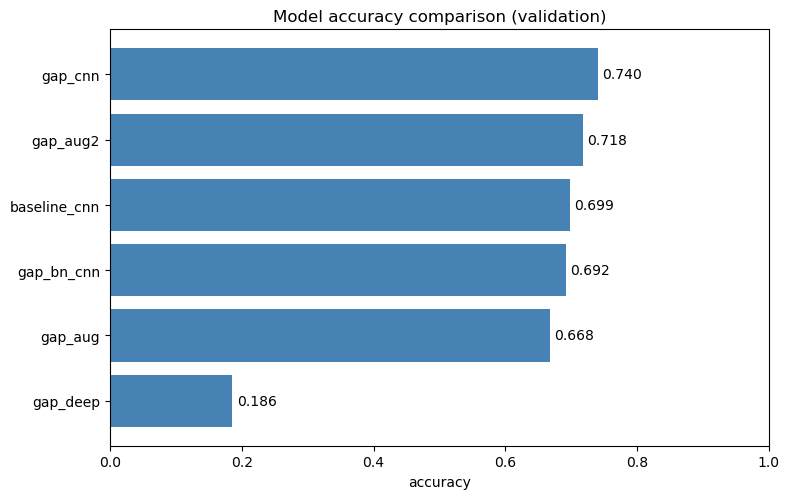

,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
1,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,FAILED to train: plain deep CNN collapsed to ~...
5,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
4,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
2,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
0,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
3,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...


In [11]:
# Accuracy comparison across every model tracked so far (reads model_tracking.csv).
from model_metrics import plot_accuracy_comparison

plot_accuracy_comparison()